In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import tree
from sklearn import metrics
from sklearn import model_selection

In [48]:
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\voice_gender.csv')
df

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402905,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3163,0.131884,0.084734,0.153707,0.049285,0.201144,0.151859,1.762129,6.630383,0.962934,0.763182,...,0.131884,0.182790,0.083770,0.262295,0.832899,0.007812,4.210938,4.203125,0.161929,female
3164,0.116221,0.089221,0.076758,0.042718,0.204911,0.162193,0.693730,2.503954,0.960716,0.709570,...,0.116221,0.188980,0.034409,0.275862,0.909856,0.039062,3.679688,3.640625,0.277897,female
3165,0.142056,0.095798,0.183731,0.033424,0.224360,0.190936,1.876502,6.604509,0.946854,0.654196,...,0.142056,0.209918,0.039506,0.275862,0.494271,0.007812,2.937500,2.929688,0.194759,female
3166,0.143659,0.090628,0.184976,0.043508,0.219943,0.176435,1.591065,5.388298,0.950436,0.675470,...,0.143659,0.172375,0.034483,0.250000,0.791360,0.007812,3.593750,3.585938,0.311002,female


In [49]:
df.isnull().sum().sum()
# 0

0

In [50]:
X, y = df.drop('label', axis=1), df[['label']]

In [51]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (2534, 20)
Test shape: (634, 20)


0.9558359621451105


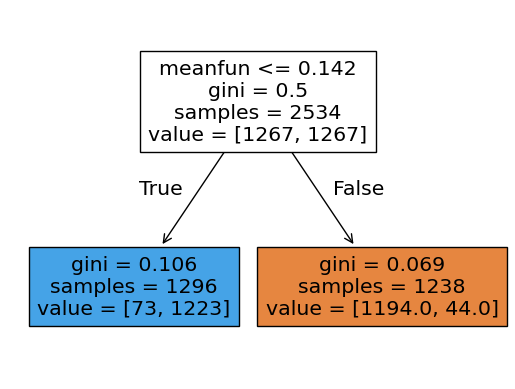

In [52]:
short_tree = tree.DecisionTreeClassifier(max_depth=1)
short_tree.fit(X_train, y_train)
y_pred_short_tree = short_tree.predict(X_test)
tree.plot_tree(short_tree, feature_names=X.columns, filled=True, impurity=True);
print(metrics.accuracy_score(y_test, y_pred_short_tree))

0.9621451104100947


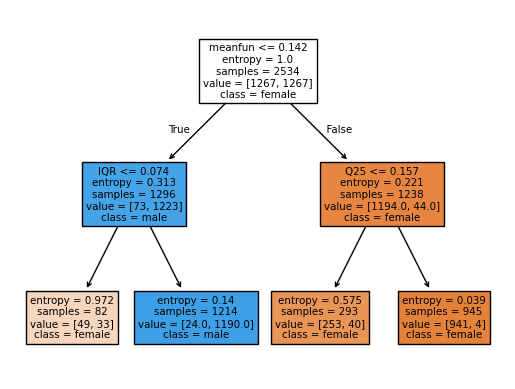

In [53]:
short_tree_2 = tree.DecisionTreeClassifier(max_depth=2, criterion='entropy')
short_tree_2.fit(X_train, y_train)
y_pred_short_tree_2 = short_tree_2.predict(X_test)
tree.plot_tree(short_tree_2, feature_names=X_train.columns, impurity=True, filled=True, class_names=short_tree_2.classes_);
print(metrics.accuracy_score(y_test, y_pred_short_tree_2))

In [57]:
trees = tree.DecisionTreeClassifier(random_state=0, criterion='entropy')
trees.fit(X_train, y_train)
y_pred_trees_test = trees.predict(X_test)
y_pred_trees_train = trees.predict(X_train)
print(metrics.accuracy_score(y_test, y_pred_trees_test))
print(metrics.accuracy_score(y_train, y_pred_trees_train))

0.973186119873817
1.0


In [58]:
trees.get_depth()

12

In [59]:
trees.get_n_leaves()

54

In [62]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'], #критерий информативности
    'max_depth': [4, 5, 6, 7, 8, 9, 10], #максимальная глубина дерева
    'min_samples_split': [3, 4, 5, 10] #минимальное количество объектов, необходимое для сплита
}
cv = model_selection.StratifiedKFold(n_splits=5)


grid = GridSearchCV(estimator=tree.DecisionTreeClassifier(random_state=0),
                    param_grid=param_grid,
                    scoring='accuracy',
                    cv=cv)
grid.fit(X_train, y_train)

,estimator,DecisionTreeC...andom_state=0)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [4, 5, ...], 'min_samples_split': [3, 4, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [66]:
treed = grid.best_estimator_

In [67]:
y_train_treed = treed.predict(X_train)
y_test_treed = treed.predict(X_test)
print(metrics.accuracy_score(y_train, y_train_treed))
print(metrics.accuracy_score(y_test, y_test_treed))

0.9956590370955012
0.9700315457413249


<Axes: xlabel='Название', ylabel='Важность'>

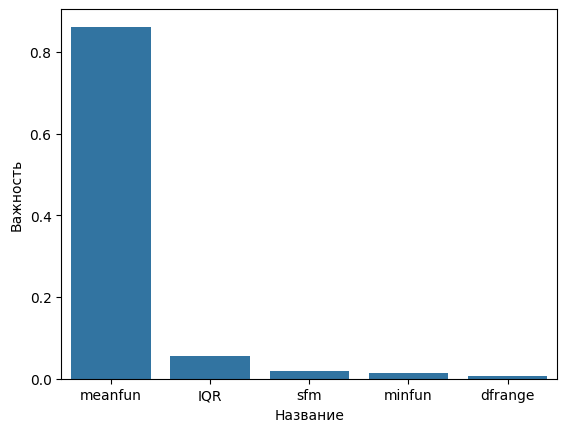

In [83]:
importa = treed.feature_importances_
col = treed.feature_names_in_
data = pd.DataFrame({'Название' : col, 'Важность' : importa}).sort_values('Важность', ascending=False)
sns.barplot(data=data[:5], x='Название', y='Важность')


In [84]:
import numpy as np
n = np.array([4.4, 3.8, 4.8, 4.0, 3.4, 4.2, 5.2])
print(np.std(n)**2)

0.3167346938775512
